# Spatial Refinement Results — Paper-Quality Visualizations

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── Thesis-Quality Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif', 'Georgia'],
    'font.size':           10,
    'axes.titlesize':      11,
    'axes.titleweight':    'bold',
    'axes.titlepad':       8,
    'axes.labelsize':      10,
    'axes.labelpad':       4,
    'axes.linewidth':      0.7,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'xtick.labelsize':     9,
    'ytick.labelsize':     9,
    'xtick.direction':     'out',
    'ytick.direction':     'out',
    'xtick.major.size':    3,
    'ytick.major.size':    3,
    'xtick.major.width':   0.7,
    'ytick.major.width':   0.7,
    'legend.fontsize':     8.5,
    'legend.framealpha':   0.95,
    'legend.edgecolor':    '#cccccc',
    'legend.borderpad':    0.5,
    'axes.grid':           True,
    'grid.linestyle':      '--',
    'grid.linewidth':      0.45,
    'grid.color':          '#d8d8d8',
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
    'savefig.pad_inches':  0.05,
    'figure.constrained_layout.use': False,
})

# ── Colour Palette ────────────────────────────────────────────────────────────
MODEL_PALETTE = {
    'Naive':        '#595959',
    'Persistence+': '#4E79A7',
    'SMA':          '#F28E2B',
    'ARIMA':        '#59A14F',
    'SARIMA':       '#9C755F',
    'Transformer':  '#E15759',
}

# Metric index mapping
# Each model/horizon entry: [raw, spatially_refined, pct_improvement]
RAW_IDX  = 0
REF_IDX  = 1
PCT_IDX  = 2

HORIZONS = [1, 7, 30]           # forecast horizons (days)
HORIZON_LABELS = ['1-day', '7-day', '30-day']

print('Environment ready.')

Environment ready.


In [2]:
# ── Load Results ──────────────────────────────────────────────────────────────
RESULTS_PATH = 'spatial_refinement_results.json'

with open(RESULTS_PATH) as f:
    results = json.load(f)

models   = list(results.keys())
print(f'Models  : {models}')
print(f'Horizons: {list(results[models[0]].keys())}')
print(f'Metrics : {list(results[models[0]]["1"].keys())}')

Models  : ['ARIMA', 'Naive', 'Persistence+', 'SARIMA', 'SMA', 'Transformer']
Horizons: ['1', '7', '30']
Metrics : ['RMSE', 'MAE']


In [3]:
# ── Helper: extract flat DataFrame ───────────────────────────────────────────
def build_df(results, metric='RMSE'):
    """Return tidy DataFrame with columns:
       model | horizon | raw | refined | pct_improvement
    """
    rows = []
    for model, horizons in results.items():
        for h_str, metrics in horizons.items():
            vals = metrics[metric]
            rows.append({
                'model':   model,
                'horizon': int(h_str),
                'raw':     vals[RAW_IDX],
                'refined': vals[REF_IDX],
                'pct_imp': vals[PCT_IDX],
            })
    return pd.DataFrame(rows)

df_rmse = build_df(results, 'RMSE')
df_mae  = build_df(results, 'MAE')

print(df_rmse.head(9).to_string(index=False))

       model  horizon         raw     refined   pct_imp
       ARIMA        1 3650.339528 3614.131038  0.991921
       ARIMA        7 4321.638181 4024.096295  6.884933
       ARIMA       30 4393.831639 4009.797712  8.740297
       Naive        1 4580.277532 4095.750548 10.578551
       Naive        7 5370.679685 4136.361477 22.982533
       Naive       30 5569.948696 4148.989269 25.511176
Persistence+        1 4524.467816 4066.598433 10.119851
Persistence+        7 5210.853555 4145.358043 20.447620
Persistence+       30 5171.654087 4239.221095 18.029686


---
## Figure 1 — Raw vs. Spatially-Refined Error Across Forecast Horizons

Grouped bar chart comparing raw and refined RMSE/MAE for each model × horizon combination.

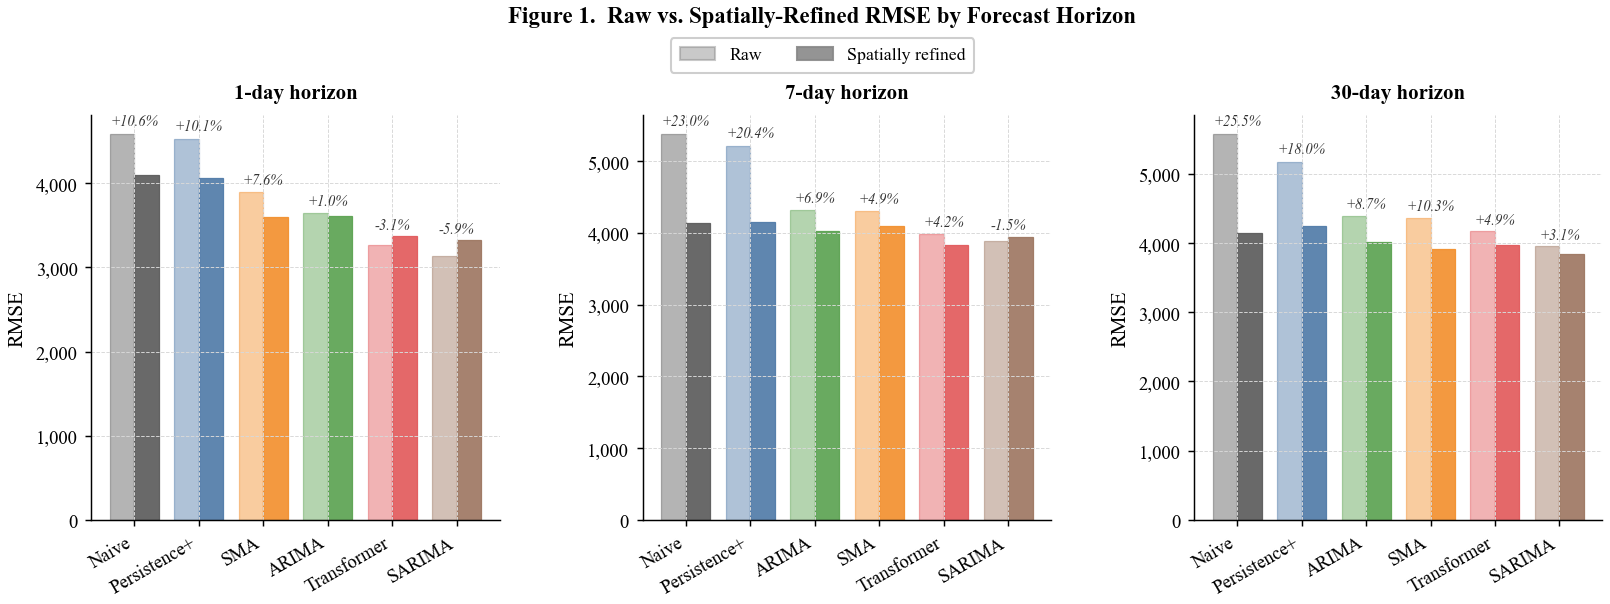

Saved fig1_grouped_bars_RMSE.pdf


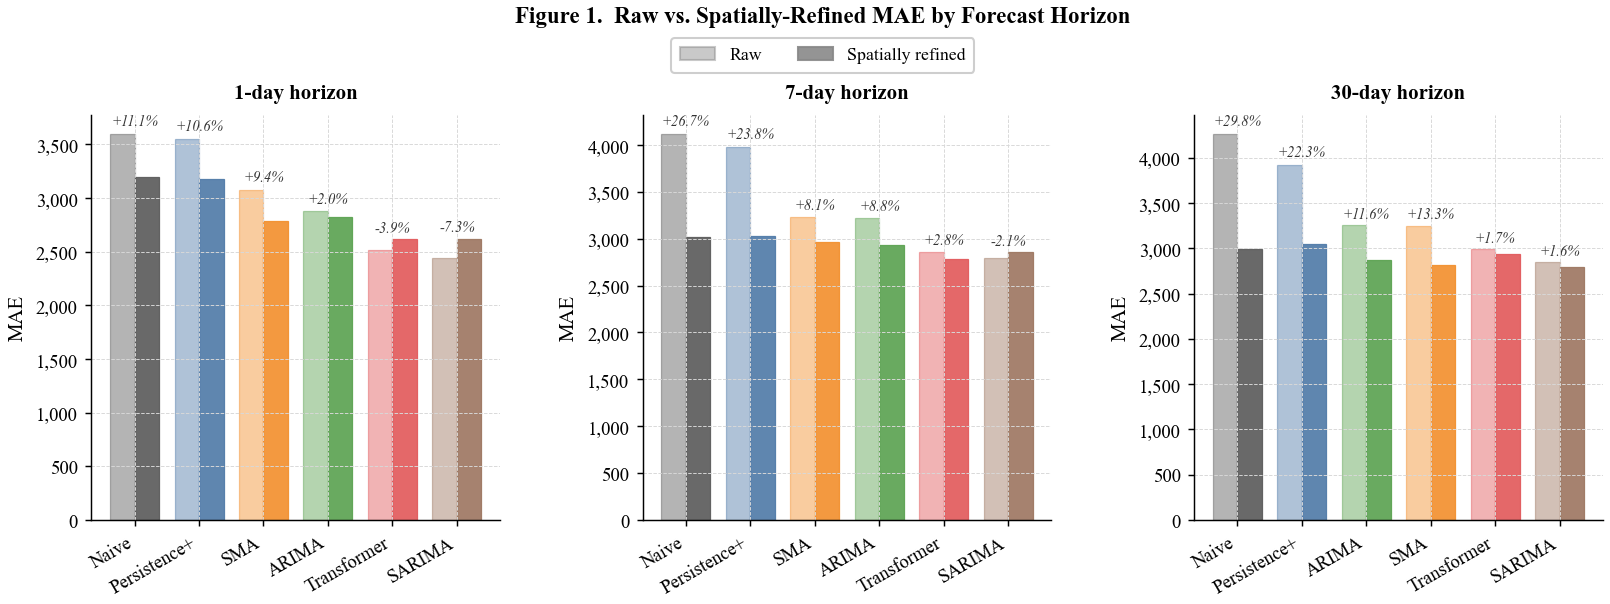

Saved fig1_grouped_bars_MAE.pdf


In [4]:
def fig_grouped_bars(df, metric_label, ax, horizon):
    """Draw grouped bars (raw vs refined) for a single horizon."""
    sub   = df[df['horizon'] == horizon].copy()
    sub   = sub.sort_values('raw', ascending=False)   # consistent ordering
    x     = np.arange(len(sub))
    width = 0.38

    colors = [MODEL_PALETTE.get(m, '#888888') for m in sub['model']]

    bars_raw = ax.bar(
        x - width/2, sub['raw'], width,
        color=colors, alpha=0.45, linewidth=0.6,
        edgecolor=[c for c in colors], label='Raw'
    )
    bars_ref = ax.bar(
        x + width/2, sub['refined'], width,
        color=colors, alpha=0.90, linewidth=0.6,
        edgecolor=[c for c in colors], label='Spatially refined'
    )

    # Percentage improvement annotation
    for i, (_, row) in enumerate(sub.iterrows()):
        y_top = max(row['raw'], row['refined'])
        sign  = '+' if row['pct_imp'] > 0 else ''
        ax.text(
            i, y_top * 1.015,
            f"{sign}{row['pct_imp']:.1f}%",
            ha='center', va='bottom', fontsize=7,
            color='#333333', style='italic'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(sub['model'], rotation=30, ha='right')
    ax.set_title(f'{horizon}-day horizon', fontsize=10, fontweight='bold')
    ax.set_ylabel(metric_label)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))


for metric_label, df in [('RMSE', df_rmse), ('MAE', df_mae)]:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
    fig.subplots_adjust(wspace=0.35, top=0.82)

    for ax, h in zip(axes, HORIZONS):
        fig_grouped_bars(df, metric_label, ax, h)

    # Unified legend (raw vs refined hatching)
    legend_handles = [
        mpatches.Patch(facecolor='#888888', alpha=0.45, edgecolor='#888888', label='Raw'),
        mpatches.Patch(facecolor='#888888', alpha=0.90, edgecolor='#888888', label='Spatially refined'),
    ]
    fig.legend(
        handles=legend_handles, ncol=2,
        loc='upper center', bbox_to_anchor=(0.5, 0.97),
        frameon=True, fontsize=8.5
    )
    fig.suptitle(
        f'Figure 1.  Raw vs. Spatially-Refined {metric_label} by Forecast Horizon',
        fontsize=11, fontweight='bold', y=1.01
    )

    plt.savefig(f'fig1_grouped_bars_{metric_label}.pdf')
    plt.show()
    print(f'Saved fig1_grouped_bars_{metric_label}.pdf')

---
## Figure 2 — Spatial Refinement Gain (% Improvement) Heatmap

Rows = models, columns = forecast horizons. Color encodes % improvement achieved by spatial refinement.

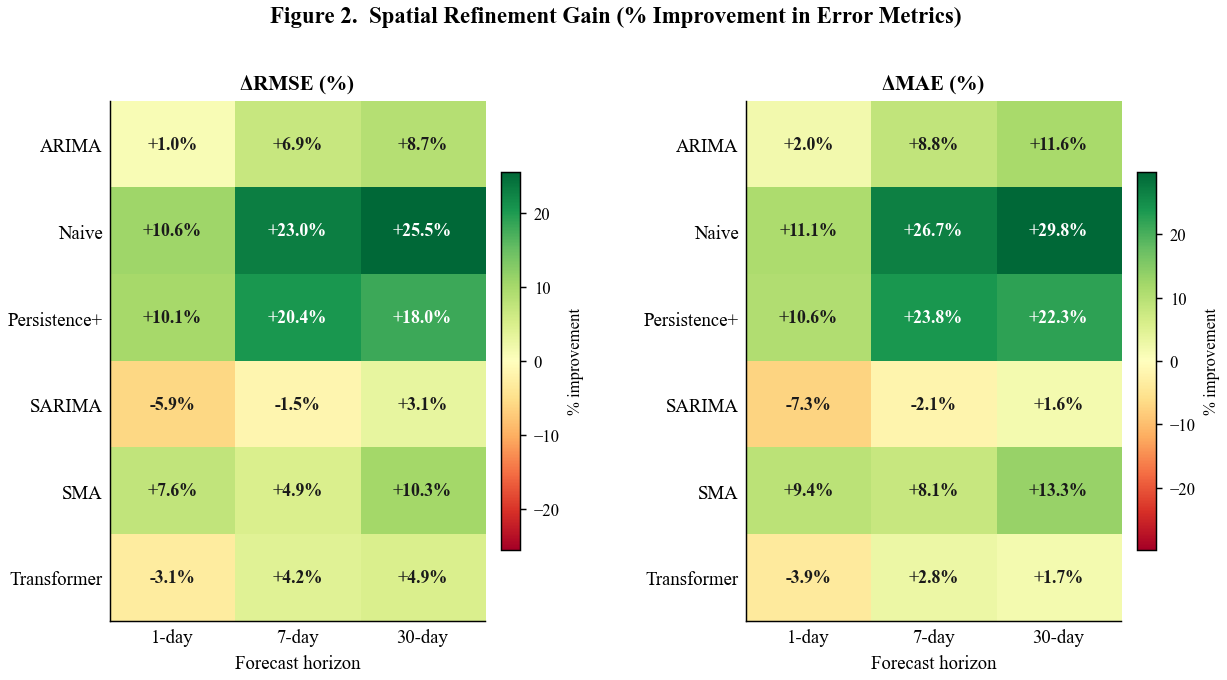

Saved fig2_improvement_heatmap.pdf


In [5]:
import matplotlib.colors as mcolors

def pct_heatmap(df, metric_label, ax, cbar_ax=None):
    pivot = (
        df.pivot(index='model', columns='horizon', values='pct_imp')
          .reindex(columns=HORIZONS)
    )

    # Color: positive = improvement (green), negative = degradation (red)
    vmax = max(abs(pivot.values.min()), abs(pivot.values.max()))
    cmap = plt.get_cmap('RdYlGn')   # paper-friendly diverging
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    im = ax.imshow(pivot.values, cmap=cmap, norm=norm, aspect='auto')

    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels(HORIZON_LABELS, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_xlabel('Forecast horizon', fontsize=9)
    ax.grid(False)
    ax.tick_params(axis='both', which='both', length=0)

    # Annotate each cell
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val  = pivot.values[r, c]
            sign = '+' if val > 0 else ''
            luma = cmap(norm(val))[:3]   # RGB
            luma_val = 0.299*luma[0] + 0.587*luma[1] + 0.114*luma[2]
            txt_color = 'white' if luma_val < 0.5 else '#1a1a1a'
            ax.text(
                c, r, f'{sign}{val:.1f}%',
                ha='center', va='center',
                fontsize=8.5, color=txt_color, fontweight='bold'
            )

    return im


fig, axes = plt.subplots(
    1, 2, figsize=(9, max(2.5, len(models) * 0.55 + 1.2)),
    gridspec_kw={'wspace': 0.55}
)

for ax, (df, label) in zip(axes, [(df_rmse, 'RMSE'), (df_mae, 'MAE')]):
    im = pct_heatmap(df, label, ax)
    ax.set_title(f'Δ{label} (%)', fontsize=10, fontweight='bold', pad=6)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=8)
    cb.set_label('% improvement', fontsize=8)

fig.suptitle(
    'Figure 2.  Spatial Refinement Gain (% Improvement in Error Metrics)',
    fontsize=11, fontweight='bold', y=1.02
)

plt.savefig('fig2_improvement_heatmap.pdf')
plt.show()
print('Saved fig2_improvement_heatmap.pdf')

---
## Figure 3 — Error vs. Forecast Horizon (Line Plot)

Solid line = raw error; dashed line = spatially-refined error. Each model is a distinct color. Shaded region = refinement gain.

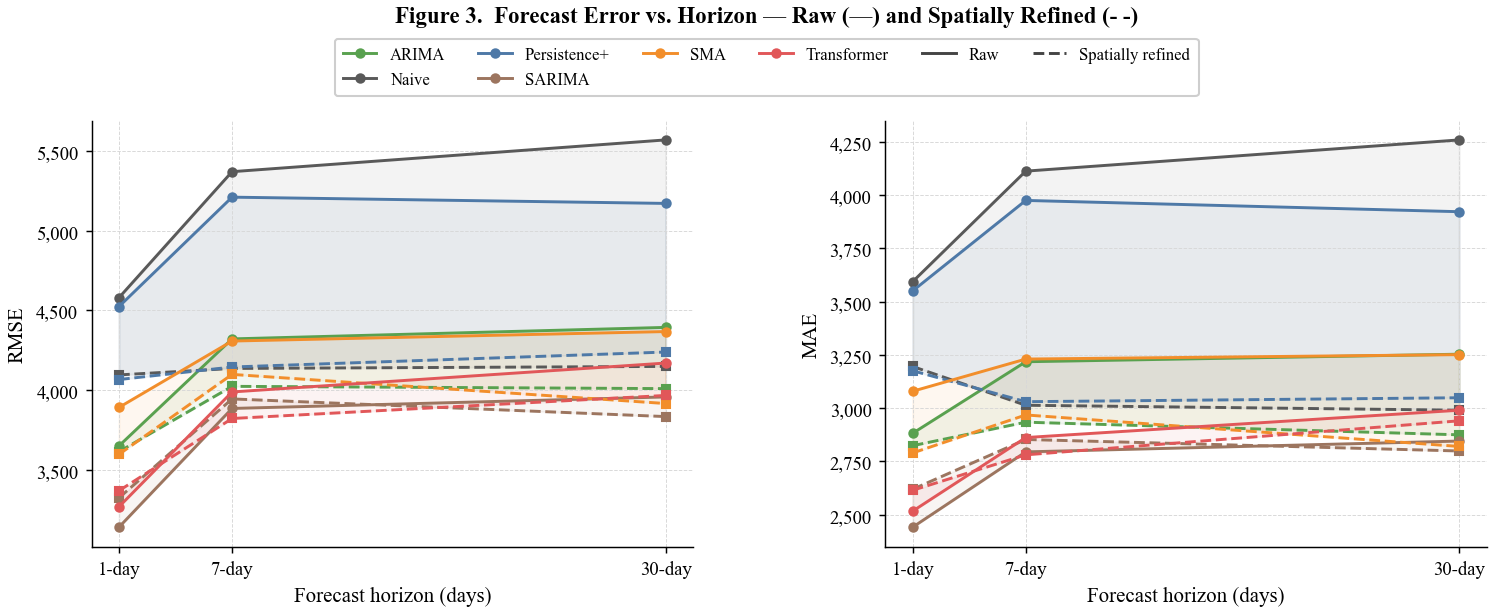

Saved fig3_horizon_lines.pdf


In [6]:
def horizon_lines(df, metric_label, ax):
    for model in models:
        sub    = df[df['model'] == model].sort_values('horizon')
        color  = MODEL_PALETTE.get(model, '#888888')
        h_vals = sub['horizon'].values

        ax.plot(
            h_vals, sub['raw'],
            color=color, linewidth=1.4, linestyle='-',
            marker='o', markersize=4, label=model if metric_label == 'RMSE' else None
        )
        ax.plot(
            h_vals, sub['refined'],
            color=color, linewidth=1.4, linestyle='--',
            marker='s', markersize=3.5
        )
        # Shaded improvement region
        ax.fill_between(
            h_vals, sub['refined'], sub['raw'],
            color=color, alpha=0.07
        )

    ax.set_xlabel('Forecast horizon (days)')
    ax.set_ylabel(metric_label)
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels(HORIZON_LABELS)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.0))
fig.subplots_adjust(wspace=0.32, top=0.82)

horizon_lines(df_rmse, 'RMSE', ax1)
horizon_lines(df_mae,  'MAE',  ax2)

# Legend: models + line-style key
model_handles = [
    Line2D([0], [0], color=MODEL_PALETTE.get(m, '#888'), linewidth=1.4,
           marker='o', markersize=4, label=m)
    for m in models
]
style_handles = [
    Line2D([0], [0], color='#444', linewidth=1.4, linestyle='-',  label='Raw'),
    Line2D([0], [0], color='#444', linewidth=1.4, linestyle='--', label='Spatially refined'),
]
fig.legend(
    handles=model_handles + style_handles,
    ncol=min(len(models) + 2, 6),
    loc='upper center', bbox_to_anchor=(0.5, 0.97),
    frameon=True, fontsize=8
)
fig.suptitle(
    'Figure 3.  Forecast Error vs. Horizon — Raw (—) and Spatially Refined (- -)',
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig('fig3_horizon_lines.pdf')
plt.show()
print('Saved fig3_horizon_lines.pdf')

---
## Figure 4 — Scatter: Raw vs. Refined Error (All Models × Horizons)

Points below the diagonal line indicate improvement from spatial refinement. Marker shape = horizon; color = model.

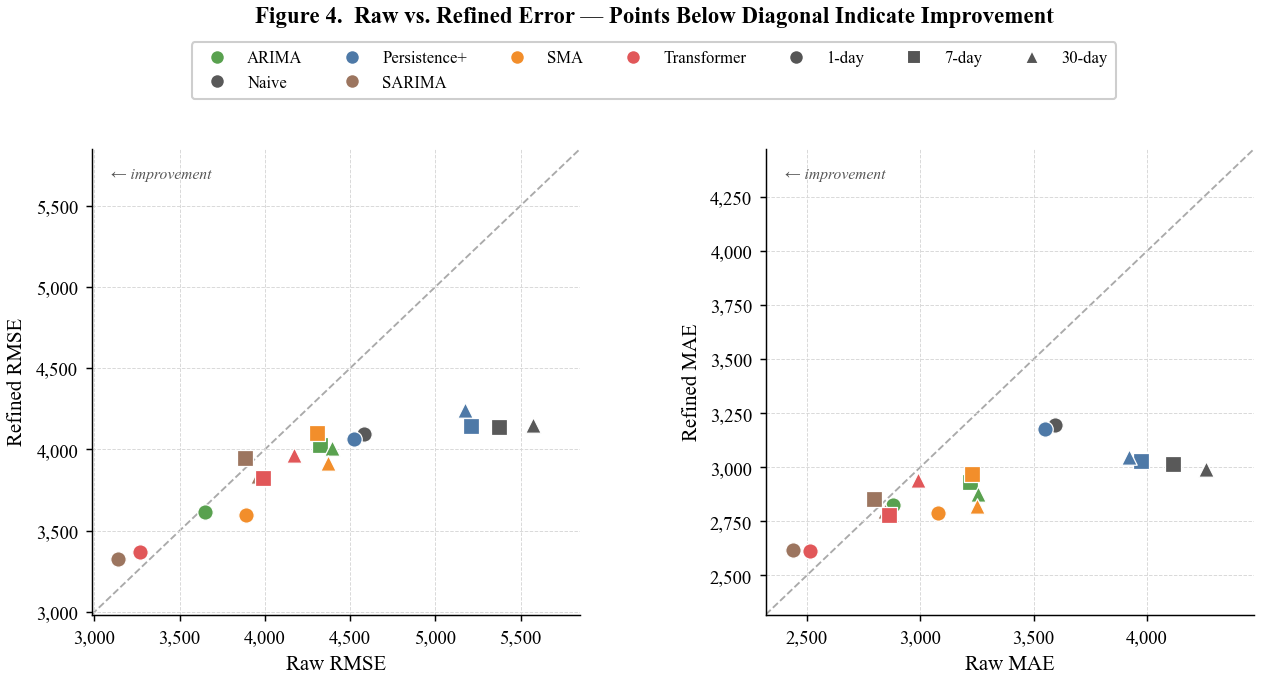

Saved fig4_scatter_raw_refined.pdf


In [7]:
HORIZON_MARKERS = {1: 'o', 7: 's', 30: '^'}

def scatter_raw_vs_refined(df, metric_label, ax):
    all_vals = pd.concat([df['raw'], df['refined']])
    lim      = (all_vals.min() * 0.95, all_vals.max() * 1.05)

    # Identity line
    ax.plot(lim, lim, color='#aaaaaa', linewidth=0.9, linestyle='--', zorder=1)

    for (model, h), grp in df.groupby(['model', 'horizon']):
        ax.scatter(
            grp['raw'], grp['refined'],
            color=MODEL_PALETTE.get(model, '#888'),
            marker=HORIZON_MARKERS[h],
            s=55, linewidths=0.6,
            edgecolors='white', zorder=3
        )

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'Raw {metric_label}')
    ax.set_ylabel(f'Refined {metric_label}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

    ax.text(
        0.04, 0.96, '← improvement',
        transform=ax.transAxes, fontsize=7.5,
        va='top', ha='left', color='#555', style='italic'
    )


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
fig.subplots_adjust(wspace=0.38, top=0.80)

scatter_raw_vs_refined(df_rmse, 'RMSE', ax1)
scatter_raw_vs_refined(df_mae,  'MAE',  ax2)

# Legend: models (color)
model_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=MODEL_PALETTE.get(m,'#888'),
           markersize=7, label=m)
    for m in models
]
# Legend: horizons (shape)
horizon_handles = [
    Line2D([0],[0], marker=mk, color='w', markerfacecolor='#555',
           markersize=7, label=f'{h}-day')
    for h, mk in HORIZON_MARKERS.items()
]
fig.legend(
    handles=model_handles + horizon_handles,
    ncol=min(len(models) + 3, 7),
    loc='upper center', bbox_to_anchor=(0.5, 0.97),
    frameon=True, fontsize=8
)
fig.suptitle(
    'Figure 4.  Raw vs. Refined Error — Points Below Diagonal Indicate Improvement',
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig('fig4_scatter_raw_refined.pdf')
plt.show()
print('Saved fig4_scatter_raw_refined.pdf')

---
## Table 1 — Summary Statistics (LaTeX-ready)

Full numerical results formatted for direct inclusion in a paper.

In [8]:
from IPython.display import display

def make_summary_table(results):
    rows = []
    for metric in ['RMSE', 'MAE']:
        df = build_df(results, metric)
        for _, row in df.iterrows():
            rows.append({
                'Metric':    metric,
                'Model':     row['model'],
                'Horizon':   f"{row['horizon']}-day",
                'Raw':       f"{row['raw']:,.1f}",
                'Refined':   f"{row['refined']:,.1f}",
                'Δ (%)':     f"{row['pct_imp']:+.2f}%",
            })
    return pd.DataFrame(rows)


summary = make_summary_table(results)

# ── Display ───────────────────────────────────────────────────────────────────
display(summary.style
    .set_caption('Table 1. Spatial Refinement Results — Raw and Refined Error Metrics')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-weight', 'bold'), ('font-size', '11px')]
    }])
    .hide(axis='index')
)

# ── LaTeX export ──────────────────────────────────────────────────────────────
latex = summary.to_latex(
    index=False,
    caption='Spatial refinement results. $\\Delta$~(\\%) denotes '
            'percentage improvement of refined over raw error. '
            'Positive values indicate improvement.',
    label='tab:spatial_refinement',
    column_format='llcrrr',
    escape=False,
    bold_rows=False,
    position='t',
)
# Wrap in booktabs-style table
latex = latex.replace(
    r'\begin{tabular}',
    r'\renewcommand{\arraystretch}{1.15}' + '\n' + r'\begin{tabular}'
)
print('\n--- LaTeX Table ---')
print(latex)

with open('table1_spatial_refinement.tex', 'w') as f:
    f.write(latex)
print('Saved table1_spatial_refinement.tex')

Metric,Model,Horizon,Raw,Refined,Δ (%)
RMSE,ARIMA,1-day,"3,650.3","3,614.1",+0.99%
RMSE,ARIMA,7-day,"4,321.6","4,024.1",+6.88%
RMSE,ARIMA,30-day,"4,393.8","4,009.8",+8.74%
RMSE,Naive,1-day,"4,580.3","4,095.8",+10.58%
RMSE,Naive,7-day,"5,370.7","4,136.4",+22.98%
RMSE,Naive,30-day,"5,569.9","4,149.0",+25.51%
RMSE,Persistence+,1-day,"4,524.5","4,066.6",+10.12%
RMSE,Persistence+,7-day,"5,210.9","4,145.4",+20.45%
RMSE,Persistence+,30-day,"5,171.7","4,239.2",+18.03%
RMSE,SARIMA,1-day,"3,140.5","3,324.4",-5.86%



--- LaTeX Table ---
\begin{table}[t]
\caption{Spatial refinement results. $\Delta$~(\%) denotes percentage improvement of refined over raw error. Positive values indicate improvement.}
\label{tab:spatial_refinement}
\renewcommand{\arraystretch}{1.15}
\begin{tabular}{llcrrr}
\toprule
Metric & Model & Horizon & Raw & Refined & Δ (%) \\
\midrule
RMSE & ARIMA & 1-day & 3,650.3 & 3,614.1 & +0.99% \\
RMSE & ARIMA & 7-day & 4,321.6 & 4,024.1 & +6.88% \\
RMSE & ARIMA & 30-day & 4,393.8 & 4,009.8 & +8.74% \\
RMSE & Naive & 1-day & 4,580.3 & 4,095.8 & +10.58% \\
RMSE & Naive & 7-day & 5,370.7 & 4,136.4 & +22.98% \\
RMSE & Naive & 30-day & 5,569.9 & 4,149.0 & +25.51% \\
RMSE & Persistence+ & 1-day & 4,524.5 & 4,066.6 & +10.12% \\
RMSE & Persistence+ & 7-day & 5,210.9 & 4,145.4 & +20.45% \\
RMSE & Persistence+ & 30-day & 5,171.7 & 4,239.2 & +18.03% \\
RMSE & SARIMA & 1-day & 3,140.5 & 3,324.4 & -5.86% \\
RMSE & SARIMA & 7-day & 3,885.3 & 3,945.2 & -1.54% \\
RMSE & SARIMA & 30-day & 3,957.6 & 3,83

---
## Figure 5 — Per-Model Refinement Profile (Small Multiples)

One panel per model: dual bars (RMSE + MAE) for each horizon, with both raw and refined values.

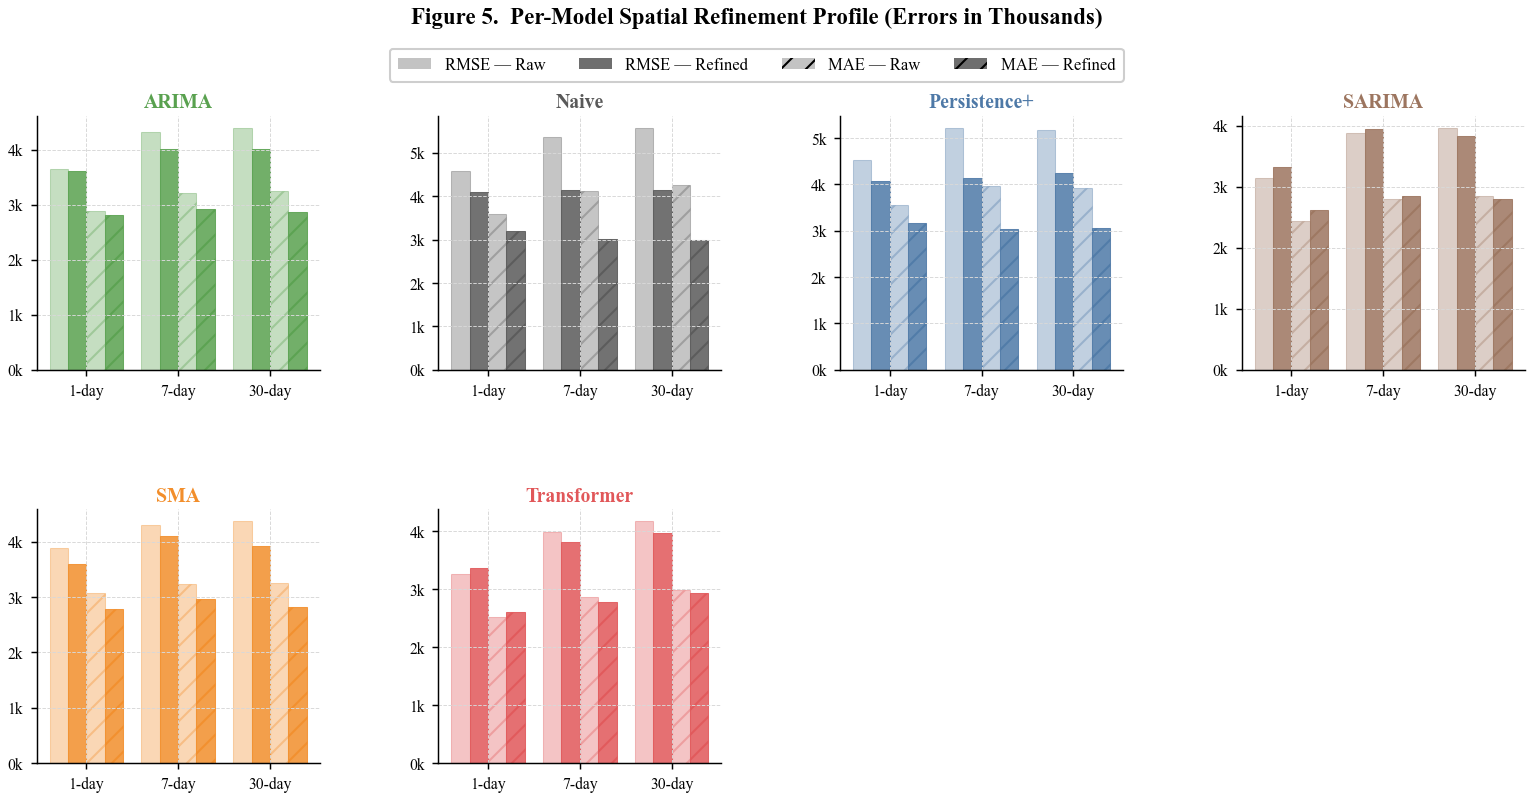

Saved fig5_small_multiples.pdf


In [9]:
n_models = len(models)
ncols    = 4
nrows    = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.2, nrows * 2.8),
    squeeze=False
)
fig.subplots_adjust(hspace=0.55, wspace=0.42, top=0.88)

x      = np.arange(len(HORIZONS))   # [0, 1, 2]
width  = 0.2

for idx, model in enumerate(models):
    r, c = divmod(idx, ncols)
    ax   = axes[r][c]
    color = MODEL_PALETTE.get(model, '#888888')

    for metric, df, offset, hatch in [
        ('RMSE', df_rmse, -width, ''),
        ('MAE',  df_mae,  +width, '//'),
    ]:
        sub = df[df['model'] == model].sort_values('horizon')

        ax.bar(
            x + offset - width/2, sub['raw'], width,
            color=color, alpha=0.35, hatch=hatch,
            edgecolor=color, linewidth=0.5
        )
        ax.bar(
            x + offset + width/2, sub['refined'], width,
            color=color, alpha=0.85, hatch=hatch,
            edgecolor=color, linewidth=0.5
        )

    ax.set_title(model, fontsize=9.5, fontweight='bold', color=color, pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels(HORIZON_LABELS, fontsize=7.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
    ax.tick_params(axis='y', labelsize=7.5)

# Hide unused panels
for idx in range(n_models, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].set_visible(False)

# Shared legend
legend_handles = [
    mpatches.Patch(facecolor='#555', alpha=0.35, hatch='',   label='RMSE — Raw'),
    mpatches.Patch(facecolor='#555', alpha=0.85, hatch='',   label='RMSE — Refined'),
    mpatches.Patch(facecolor='#555', alpha=0.35, hatch='//', label='MAE — Raw'),
    mpatches.Patch(facecolor='#555', alpha=0.85, hatch='//', label='MAE — Refined'),
]
fig.legend(
    handles=legend_handles, ncol=4,
    loc='upper center', bbox_to_anchor=(0.5, 0.97),
    frameon=True, fontsize=8
)
fig.suptitle(
    'Figure 5.  Per-Model Spatial Refinement Profile (Errors in Thousands)',
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig('fig5_small_multiples.pdf')
plt.show()
print('Saved fig5_small_multiples.pdf')